In [1]:
import pandas as pd

df = pd.read_csv("twitter_training.csv", header=None)

In [2]:
df.columns = ["ID", "Entity", "Sentiment", "Text"]

In [3]:
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [5]:
df = df[df["Sentiment"] != "Irrelevant"]

In [6]:
df["Sentiment"].value_counts()

Sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64

In [7]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Text         571
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

ID           0
Entity       0
Sentiment    0
Text         0
dtype: int64

In [10]:
df.shape

(61121, 4)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

C:\Users\navee\AppData\Local\Temp\ipykernel_5680\2438829399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


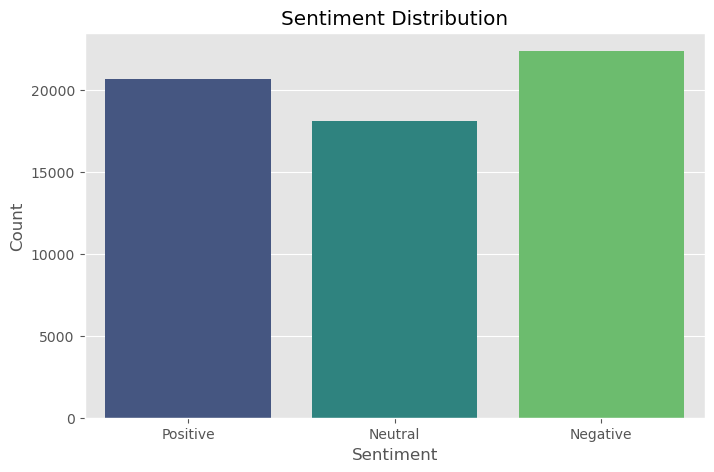

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    palette="viridis"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [13]:
df["Sentiment"].value_counts(normalize=True) * 100

Sentiment
Negative    36.579899
Positive    33.793622
Neutral     29.626479
Name: proportion, dtype: float64

In [14]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [15]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\navee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\navee\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\navee\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [17]:
def preprocess(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [18]:
df["Clean_Text"] = df["Text"].apply(preprocess)

In [19]:
df[["Text", "Clean_Text"]].head(10)

,Text,Clean_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,So I spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [21]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["Clean_Text"])

y = df["Sentiment"]

In [22]:
X.shape

(61121, 5000)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(48896, 5000)
(12225, 5000)


In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [27]:
y_pred_nb = nb_model.predict(X_test)

In [28]:
accuracy_score(y_test, y_pred_nb)

0.7167280163599182

In [29]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    Negative       0.70      0.82      0.76      4472
     Neutral       0.75      0.56      0.64      3622
    Positive       0.72      0.74      0.73      4131

    accuracy                           0.72     12225
   macro avg       0.72      0.71      0.71     12225
weighted avg       0.72      0.72      0.71     12225



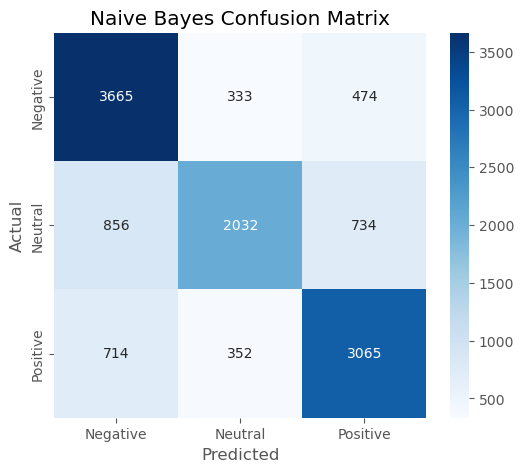

In [30]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_pred_lr = lr_model.predict(X_test)

In [34]:
    accuracy_score(y_test, y_pred_lr)

0.7555010224948875

In [35]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.79      0.80      0.79      4472
     Neutral       0.70      0.70      0.70      3622
    Positive       0.77      0.76      0.76      4131

    accuracy                           0.76     12225
   macro avg       0.75      0.75      0.75     12225
weighted avg       0.76      0.76      0.76     12225



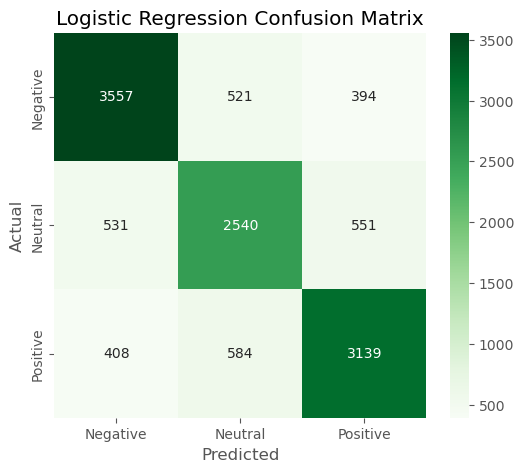

In [36]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [38]:
from wordcloud import WordCloud

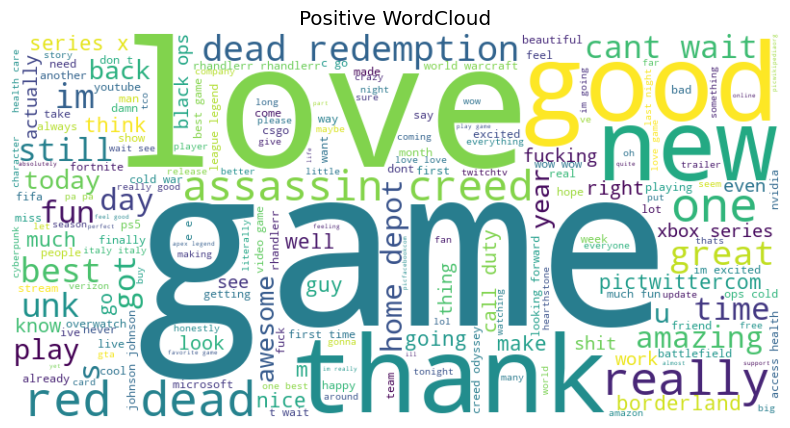

In [39]:
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive WordCloud")
plt.show()

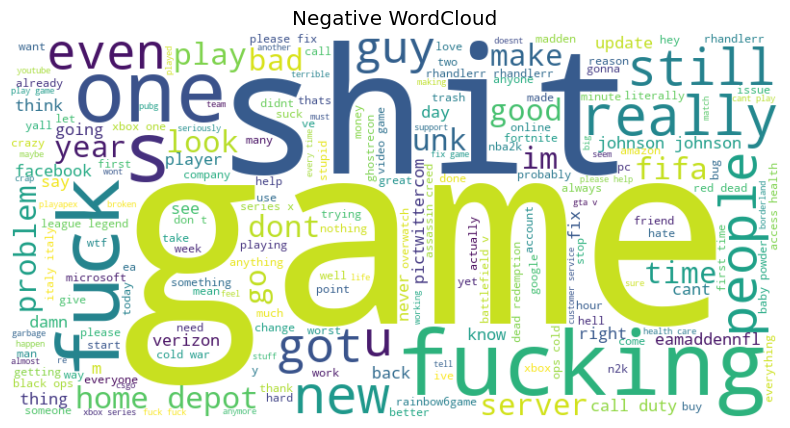

In [40]:
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative WordCloud")
plt.show()

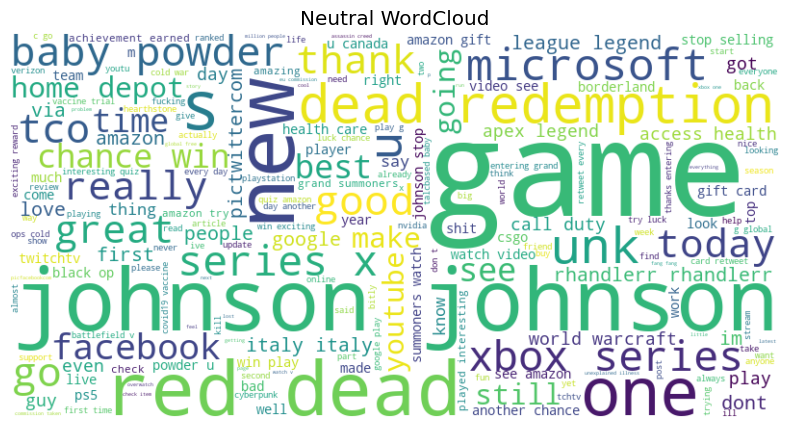

In [41]:
neutral_text = " ".join(df[df["Sentiment"] == "Neutral"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral WordCloud")
plt.show()

In [42]:
error_df = pd.DataFrame({
    "Text": df.loc[y_test.index, "Text"],
    "Actual": y_test,
    "Predicted": y_pred_lr
})

In [43]:
misclassified = error_df[error_df["Actual"] != error_df["Predicted"]]

In [44]:
misclassified.head(5)

,Text,Actual,Predicted
9125,is,Negative,Neutral
6965,at,Negative,Neutral
42299,How did i become so depressed.. i only went th...,Neutral,Negative
14355,Dad Maxwell,Negative,Positive
59934,Stupidity !,Negative,Neutral


In [45]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.716728
1,Logistic Regression,0.755501


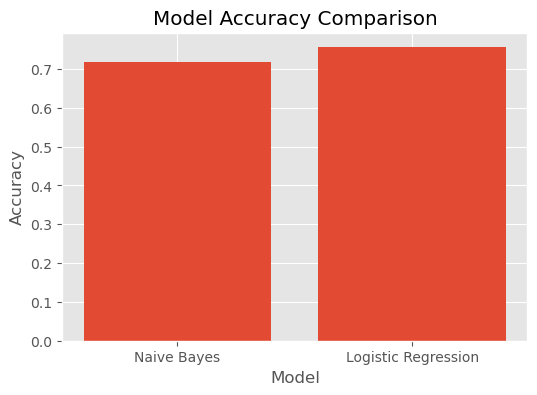

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()